In [39]:
import yfinance as yf
import pandas as pd
import time

# tickers of most liquid US stocks (example list)
liquid_tickers = [
    "AAPL", "MSFT", "AMZN", "GOOGL", 
    "TSLA", "NVDA", "META", "BRK-B", 
    "JPM", "XOM"
]

# intraday interval (lowest possible)
interval = "1m"

# define the maximum period Yahoo supports for 1m
period = "8d"  # up to 60 days for 1m

# wrapper to fetch and save
for symbol in liquid_tickers:
    print(f"Fetching {symbol} ({interval} / {period}) ...")
    ticker = yf.Ticker(symbol)
    
    try:
        df = ticker.history(
            period=period,
            interval=interval,
            actions=False
        )
        
        # check if data was returned
        if df.empty:
            print(f"⚠️ No data returned for {symbol}. Skipping.")
            continue
        
        # save
        filename = f"{symbol}_1m_{period}.csv"
        df.to_csv(filename)
        print(f"✔️ Saved {filename} ({len(df)} rows)")
        
    except Exception as e:
        print(f"❌ Error with {symbol}: {e}")
    
    # pause to avoid throttling
    time.sleep(1)

Fetching AAPL (1m / 8d) ...
✔️ Saved AAPL_1m_8d.csv (3120 rows)
Fetching MSFT (1m / 8d) ...
✔️ Saved MSFT_1m_8d.csv (3120 rows)
Fetching AMZN (1m / 8d) ...
✔️ Saved AMZN_1m_8d.csv (3120 rows)
Fetching GOOGL (1m / 8d) ...
✔️ Saved GOOGL_1m_8d.csv (3120 rows)
Fetching TSLA (1m / 8d) ...
✔️ Saved TSLA_1m_8d.csv (3120 rows)
Fetching NVDA (1m / 8d) ...
✔️ Saved NVDA_1m_8d.csv (3120 rows)
Fetching META (1m / 8d) ...
✔️ Saved META_1m_8d.csv (3120 rows)
Fetching BRK-B (1m / 8d) ...
✔️ Saved BRK-B_1m_8d.csv (3120 rows)
Fetching JPM (1m / 8d) ...
✔️ Saved JPM_1m_8d.csv (3120 rows)
Fetching XOM (1m / 8d) ...
✔️ Saved XOM_1m_8d.csv (3120 rows)


In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("deltatrup/aapl-1-minute-historical-stock-data-2006-2024")

print("Path to dataset files:", path)

/Users/tommykornfeld/Documents/projects/m86/m86/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 397M/397M [05:55<00:00, 1.17MB/s] 

Extracting files...


Path to dataset files: /Users/tommykornfeld/.cache/kagglehub/datasets/deltatrup/aapl-1-minute-historical-stock-data-2006-2024/versions/1


In [40]:
import pandas as pd
import numpy as np
import glob

files = glob.glob("*_1m_8d.csv")

all_data = []

for file in files:
    df = pd.read_csv(file, parse_dates=["Datetime"])
    df = df.sort_values("Datetime")

    # Log returns
    df["return"] = np.log(df["Close"] / df["Close"].shift(1))

    # Minute-of-day
    df["Time"] = df["Datetime"].dt.strftime("%H:%M")

    all_data.append(df[["Time", "return"]])

combined = pd.concat(all_data).dropna()

results = []

for minute, group in combined.groupby("Time"):
    returns = group["return"].values
    n = len(returns)

    if n > 1:
        sigma = np.std(returns, ddof=1)
        # vol_of_vol = sigma / np.sqrt(2 * (n - 1))

        results.append({
            "Time": minute,
            "Volatility": sigma,
            # "Vol_of_Vol_estimator": vol_of_vol,
            "Sample_Size": n
        })

intraday_profile = pd.DataFrame(results).sort_values("Time")

# intraday_profile.to_csv("intraday_vol_and_volofvol.csv", index=False)

print(intraday_profile.head())

    Time  Volatility  Sample_Size
0  09:30    0.009139           70
1  09:31    0.002879           80
2  09:32    0.002699           80
3  09:33    0.002110           80
4  09:34    0.001886           80


In [41]:
intraday_profile

,Time,Volatility,Sample_Size
0,09:30,0.009139,70
1,09:31,0.002879,80
2,09:32,0.002699,80
3,09:33,0.002110,80
4,09:34,0.001886,80
...,...,...,...
385,15:55,0.001173,80
386,15:56,0.000441,80
387,15:57,0.000821,80
388,15:58,0.000548,80


In [15]:
file_path = "/Users/tommykornfeld/.cache/kagglehub/datasets/deltatrup/aapl-1-minute-historical-stock-data-2006-2024/versions/1/aapl_1min_data From 2006 -2024.csv"
df = pd.read_csv(file_path)

In [17]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
8689179,2024-05-12 23:56:00,185.439502,187.098145,184.617690,186.277008,186.277008,7.197843e+07
8689180,2024-05-12 23:57:00,185.439627,187.098610,184.618266,186.277756,186.277756,7.198335e+07
8689181,2024-05-12 23:58:00,185.439752,187.099076,184.618842,186.278503,186.278503,7.198827e+07
8689182,2024-05-12 23:59:00,185.439877,187.099541,184.619419,186.279251,186.279251,7.199318e+07
8689183,2024-05-13 00:00:00,185.440002,187.100006,184.619995,186.279999,186.279999,7.199810e+07


In [19]:
df['rs_estimator'] = np.log(df['High'] / df['Close']) * np.log(df['High'] / df['Open']) + np.log(df['Low'] / df['Close']) * np.log(df['Low'] / df['Open'])

In [24]:
df["Date"]

0          2006-01-03 00:00:00
1          2006-01-03 00:01:00
2          2006-01-03 00:02:00
3          2006-01-03 00:03:00
4          2006-01-03 00:04:00
                  ...         
8689179    2024-05-12 23:56:00
8689180    2024-05-12 23:57:00
8689181    2024-05-12 23:58:00
8689182    2024-05-12 23:59:00
8689183    2024-05-13 00:00:00
Name: Date, Length: 8689184, dtype: str

In [32]:
import pandas as pd

# 1. Ensure the column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# 2. Group by the time component and calculate the mean
# This creates a Series where the index is the time (00:00, 00:01...) 
# and the value is the average rs_estimator for that minute.
time_averages = df.groupby(df['Date'].dt.time)['rs_estimator'].mean()
time_stds = df.groupby(df['Date'].dt.time)['rs_estimator'].std()


# 3. Map these averages back into a new column in your original dataframe
df['avg_rs_at_this_time'] = df['Date'].dt.time.map(time_averages)
df['std_rs_at_this_time'] = df['Date'].dt.time.map(time_stds)

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_hdi_numpy(series, mass=0.95):
    """
    Finds the narrowest 95% interval of the data.
    """
    # Drop NaNs and sort
    vals = series.dropna().values
    if len(vals) == 0:
        return np.nan, np.nan
    
    vals = np.sort(vals)
    n = len(vals)
    
    # Number of elements that must be inside the interval
    interval_size = int(np.floor(mass * n))
    
    # Calculate all possible intervals of that size
    # n - interval_size gives us the number of possible starting points
    n_intervals = n - interval_size
    
    # Vectorized subtraction to find the narrowest span
    widths = vals[interval_size:] - vals[:n_intervals]
    min_index = np.argmin(widths)
    
    return vals[min_index], vals[min_index + interval_size]

# 1. Group by time and apply the logic
# This will take a moment given the 8.6M rows, but NumPy makes it efficient.
hdi_bounds = df.groupby(df['Date'].dt.time)['rs_estimator'].apply(calculate_hdi_numpy)

# 2. Extract into separate series for plotting
hdi_low = hdi_bounds.apply(lambda x: x[0])
hdi_high = hdi_bounds.apply(lambda x: x[1])
time_means = df.groupby(df['Date'].dt.time)['rs_estimator'].mean()

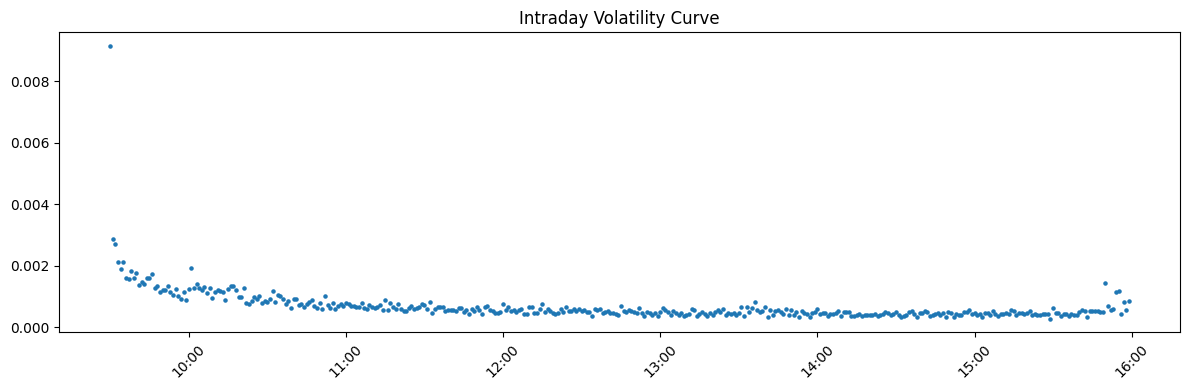

In [42]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Convert to datetime (dummy date added)
intraday_profile["Time_dt"] = pd.to_datetime(intraday_profile["Time"], format="%H:%M")

fig, ax = plt.subplots(figsize=(12,4))

ax.scatter(intraday_profile["Time_dt"],
           intraday_profile["Volatility"],
           s=5)

# Format x-axis nicely
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator())

plt.xticks(rotation=45)
plt.title("Intraday Volatility Curve")
plt.tight_layout()
plt.show()